In [1]:
#从零实现Softmax回归（动手深度学习）
#本项目完成了Softmax回归函数的从零开始实现及简介实现

In [3]:
#导入库
import torch
from IPython import display
import d2l.torch as d2l

In [4]:
#定义样本大小，提取图片数据集
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 定义数据预处理（和d2l默认一致）
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化
])

# 2. 手动指定用户目录下的数据集路径（绝对路径，避免歧义）
# 替换成你的实际用户目录，比如 C:/Users/张三 （复制你自己的用户文件夹路径！）
user_data_path = "C:/Users/Rurora/data"  

# 3. 加载训练集和测试集（download=True会自动下载，若已下载则直接读取）
train_dataset = datasets.FashionMNIST(
    root=user_data_path,  # 存储路径
    train=True,           # 训练集
    download=True,        # 自动下载（首次运行需要）
    transform=transform   # 预处理
)

test_dataset = datasets.FashionMNIST(
    root=user_data_path,
    train=False,          # 测试集
    download=True,
    transform=transform
)

# 4. 创建数据迭代器（和d2l的train_iter/test_iter功能一致）
batch_size = 256
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 验证：打印数据集数量，确认加载成功
print(f"训练集数量：{len(train_dataset)}")
print(f"测试集数量：{len(test_dataset)}")
print(f"训练迭代器批次：{len(train_iter)}")

训练集数量：60000
测试集数量：10000
训练迭代器批次：235


In [5]:
#定义输入维度，输出维度，定义权重和偏置,softmax函数只能处理一维向量
num_inputs=784
num_outputs=10
w=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad = True)
b=torch.zeros(num_outputs,requires_grad=True)

In [6]:
#定义Softmax函数,行方向求和不同类和
def softmax(x):
    x_exp = torch.exp(x)
    partition=x_exp.sum(1,keepdim=True)
    return x_exp/partition

In [7]:
#实现Softmax回归模型
def net(x):
   return softmax(torch.matmul(x.reshape((-1,w.shape[0])),w)+b)

In [8]:
#定义一个小模型，用来教学
y=torch.tensor([0,2])
y_hat=torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [21]:
#交叉熵损失函数，评估模型损失值
def cross_entrophy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y])

cross_entrophy(y_hat,y)    

tensor([2.3026, 0.6931])

In [22]:
#计算正确的数量
def accuracy(y_hat,y):
    """计算预测正确的数量"""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype)==y   
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat,y)/len(y)

0.5

In [23]:
#计算在指定数据集上的精度
def evaluate_accuracy(net,data_iter):
    """计算在指定数据集上的精度"""
    if isinstance(net,torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    for x,y in data_iter:
        metric.add(accuracy(net(x),y),y.numel())
    return metric[0]/metric[1]    

In [24]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self,n):
        self.data = [0.0]*n

    def add(self,*args):
        self.data = [a+float(b)for a,b in zip(self.data,args)]

    def reset(self):
        self.data = [0.0]*len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

evaluate_accuracy(net,test_iter)

0.4259

In [25]:
#定义训练模型
def train_epoch_ch3(net,train_iter,loss,updater):
    if isinstance(net,torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for x,y in train_iter:
        y_hat = net(x)
        l = loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            updator.zero_grad()
            l.backward()
            updater.step()
        else:
            l.sum().backward()
            updater(x.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat.detach(), y), y.numel())
    return metric[0]/metric[2],metric[1]/metric[2]   

In [26]:
import matplotlib.pyplot as plt
from IPython import display

class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: self.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def set_axes(self, ax, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
        """设置坐标轴"""
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xscale(xscale)
        ax.set_yscale(yscale)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        if legend:
            ax.legend(legend)
        ax.grid()

    def add(self, x, y):
        """向图表中添加多个数据点"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [27]:
#定义训练函数
def train_ch3(net,train_iter,test_iter,cross_entrophy,num_epochs,updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                        ylim=[0.3, 1], legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net,train_iter,cross_entrophy,updater)
        test_acc=evaluate_accuracy(net,test_iter)
        animator.add(epoch + 1, (*train_metrics, test_acc))

In [48]:
#定义优化模型
#lr = 0.1

def updater(batch_size):
    return d2l.sgd([w,b],lr,batch_size)

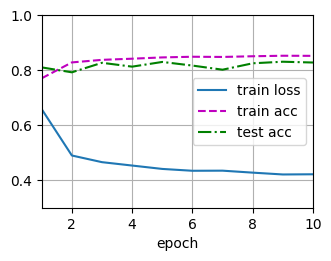

In [29]:
num_epochs = 10
train_ch3(net,train_iter,test_iter,cross_entrophy,num_epochs,updater)

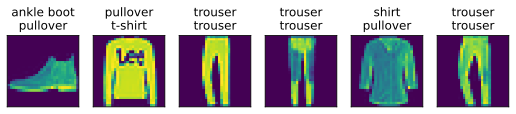

In [56]:
def predict(net,test_iter,n=6):
    """预测标签(定义见第三章)"""
    for x,y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(x).argmax(axis=1))
    titles = [true+'\n'+pred for true,pred in zip(trues,preds)]
    d2l.show_images(x[0:n].reshape(n, 28, 28), 1, n, titles=titles[0:n])
predict(net,test_iter)

In [41]:
#Softmax回归的简洁实现
#初始化
import torch.nn as nn
net = nn.Sequential(nn.Flatten(),nn.Linear(784,10))

def init_weights(m):
    if(type(m))==nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights);

In [51]:
#选择损失函数和优化器
loss = nn.CrossEntropyLoss()
#trainer = torch.optim.SGD(net.parameters(),lr=0.1)

loss 0.424, train acc 0.852, test acc 0.814
227493.9 examples/sec on cpu


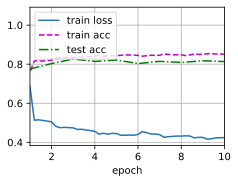

In [58]:
#开始训练
num_epochs = 10
d2l.train_ch6(net,train_iter,test_iter,num_epochs=num_epochs,lr = 0.1,device = 'cpu')